In [349]:
import numpy as np
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

import matplotlib.pyplot as plt

import pandas as pd

import scipy.optimize as opt

Outline for this project

* take notes on the VQLS paper
    - implement VQLS on some basic scale

* scale up the qubits/simulate on IBM QPU
* use cuda-q to simulate too maybe
* learn HPC to run training loop

* find barren plateaus?
    * DLA!


# Simple 3-qubit example

$ A = c_0 A_0 + c_1 A_1 + c_2 A_2 \\ A = I + 0.2 X_0 Z_1 + 0.2 X_0 $

$ |b \rangle = U | 000 \rangle = H_0 H_1 H_2 |000 \rangle $

A simple ansatz can be used:

$ V(\alpha) = R_y(\alpha_0) \otimes R_y(\alpha_1) \otimes R_y(\alpha_2) \\ V(\alpha)|0 \rangle = |x \rangle$


ParameterView([Parameter(α_0), Parameter(α_1), Parameter(α_2)])

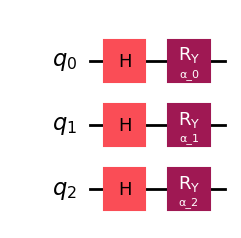

In [350]:
n_qubits = 3
n_shots = 10 ** 6

total_qubits = n_qubits + 1
ancilla_idx = n_qubits

q_delta = 0.001 # intial spread of random quantum weights
rng_seed = 23498

# U gate
Ub = qiskit.QuantumCircuit(3)
for i in range(n_qubits):
    Ub.h(i)

Ub.draw('mpl')

# generate controlled A gate:

coefficients = np.array([1.0, 0.2, 0.2])

def controlled_A(i):
    circuit = qiskit.QuantumCircuit(total_qubits)

    match(i):
        case 0:
            pass # identity
        case 1:
            circuit.cx(ancilla_idx, 0)
            circuit.cz(ancilla_idx, 1)
        case 2:
            circuit.cx(ancilla_idx, 0)  

    return circuit

# Variational form

V = qiskit.QuantumCircuit(n_qubits)
α_in = [Parameter(f'α_{i}') for i in range(n_qubits)]

for i in range(n_qubits):
    V.h(i)
for i in range(n_qubits):
    V.ry(α_in[i], i)

display(V.parameters)

V.draw('mpl')

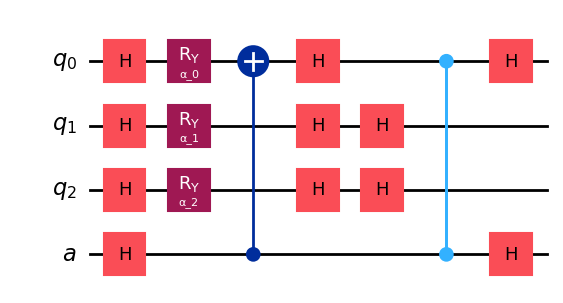

array([[0.]])

In [ ]:
# hadamard test

def local_hadamard_test(weights, l: int=0, lp: int=0, j: int=0, part: str=""):
    system = QuantumRegister(3, name='q')
    ancilla = QuantumRegister(1, name='a')
    circuit = QuantumCircuit(system, ancilla)

    # first hadamard for the hadamard test
    circuit.h(ancilla_idx)

    if part.lower() == 'im':
        # phase shift by -pi/2
        θ = -np.pi / 2

        circuit.p(θ, ancilla_idx)

    # apply ansatz
    circuit.compose(V, inplace=True)

    circuit.compose(controlled_A(l), inplace=True)

    # typically would be the adjoint of U but U_dag = U in this case
    circuit.compose(Ub, inplace=True)

    if j != -1:
        circuit.cz(ancilla_idx, j)

    circuit.compose(Ub, inplace=True)

    circuit.compose(controlled_A(lp), inplace=True)

    circuit.h(ancilla_idx)

    observables = [[SparsePauliOp(["ZIII"])]]
    estimator = StatevectorEstimator()

    pub = (circuit, observables, weights)
    job = estimator.run([pub])

    evs = job.result()[0].data.evs

    return evs, circuit


evs, circuit = local_hadamard_test(np.zeros(n_qubits), l=2)

display(circuit.draw('mpl'))
evs


Now we need to run the local hadamard test to get the real and imaginary parts of $ \mu _{l,l',j}$

In [352]:
# get the real and imaginary parts of μ 
def mu(weights, l: int=None, lp: int=None, j: int=None):
    mu_real = local_hadamard_test(weights, l=l, lp=lp, j=j, part='re')[0]
    mu_imag = local_hadamard_test(weights, l=l, lp=lp, j=j, part='im')[0]

    # display(circuit)

    return mu_real + 1.0j * mu_imag

Define the local cost function to estimate ψ
$$| \psi \rangle = \langle x | A^\dagger A | x \rangle $$

$$C_L = \frac{1}{2} - \frac{1}{2n} \frac{\sum c_l c_{l'}^* \langle 0 | V^\dagger A_{l'}^\dagger U Z_j U^\dagger A_l V | 0 \rangle}{\sum c_l c_{l'}^* \langle 0 | V^\dagger A_{l'}^\dagger  A_l V | 0 \rangle}$$


In [353]:
# define the norm
def norm(weights):
    norm = 0.0

    for l in range(0, len(coefficients)):
        for lp in range(0, len(coefficients)):
            norm += coefficients[l] * np.conj(coefficients[lp]) * mu(weights, l, lp, -1)

    return abs(norm)

# define the local cost function
def local_cost(weights):
    mu_sum = 0.0

    for l in range(0, len(coefficients)):
        for lp in range(0, len(coefficients)):
            for j in range(0, n_qubits):
                mu_sum += coefficients[l] * np.conj(coefficients[lp]) * mu(weights, l, lp, j)

    mu_sum = abs(mu_sum)
    return 0.5 - 0.5 * mu_sum / (n_qubits * norm(weights))


In [354]:
np.random.seed(rng_seed)
α = q_delta * np.random.randn(n_qubits)
α

array([ 0.00180785, -0.00095089,  0.00012278])

array([[0.05172414]])

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 0.05172413793102576
       x: [ 1.808e-03  4.911e-05  1.000e+00]
     nit: 27
   maxcv: 0.0
    nfev: 25

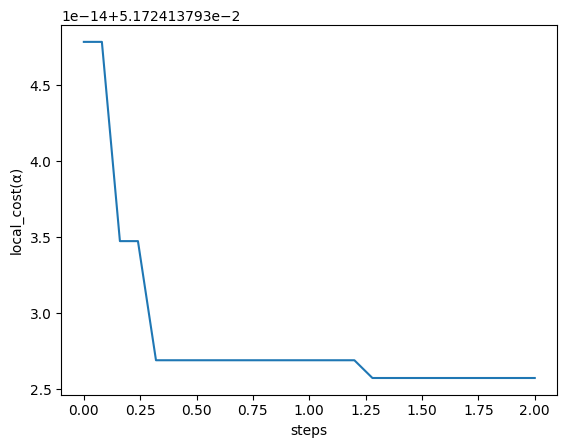

In [355]:
history = []
def log_step(xk):
    cost = local_cost(xk)
    history.append(np.copy(cost))

# history.append(np.copy())
log_step(α)

res = opt.minimize(local_cost, α, method="COBYQA", callback=log_step)

xs = np.linspace(0, 2, len(history))

plt.plot(xs, [h[0][0] for h in history])
plt.xlabel("steps")
plt.ylabel("local_cost(α)")
display(history[-1])
res


# Check solution

$ A = c_0 A_0 + c_1 A_1 + c_2 A_2 \\ A = I + 0.2 X_0 Z_1 + 0.2 X_0 $

$ |b \rangle = U | 000 \rangle = H_0 H_1 H_2 |000 \rangle $

$ V(\alpha) = R_y(\alpha_0) \otimes R_y(\alpha_1) \otimes R_y(\alpha_2) \\ V(\alpha)|0 \rangle = |x \rangle$


In [356]:
# classically compute
I = np.eye(2)
H = np.array([
    [1, 1],
    [1, -1]
]) / np.sqrt(2)
Z = np.array([
    [1, 0],
    [0, -1]
])
X = np.array([
    [0, 1],
    [1, 0]
])

A_0 = np.eye(8) # 2^3
A_1 = coefficients[1] * np.kron(np.kron(X, Z), I)
A_2 = coefficients[2] * np.kron(np.kron(X, I), I)
Am = A_0 + A_1 + A_2

# compute cost function analytically to debug
Um = np.kron(np.kron(H, H), H)

Ry = lambda θ: np.array([
    [np.cos(θ), -np.sin(θ)],
    [np.sin(θ), np.cos(θ)]
])

Vm = lambda α: np.kron(np.kron(Ry(α[0]), Ry(α[1])), Ry(α[2]))

def Zm(j=0):
    match j:
        case -1:
            return A_0
        case 0:
            return np.kron(np.kron(Z, I), I)
        case 1:
            return np.kron(np.kron(I, Z), I)
        case 2:
            return np.kron(np.kron(I, I), Z)

def μm(α=[0, 0, 0], j=-1):
    ket0 = np.array([
        [1],
        [0]
    ])
    ket0tp3 = np.kron(np.kron(ket0, ket0), ket0)

    return np.conj(ket0tp3).T @ np.conj(Vm(α)).T @ np.conj(Am).T @ Um @ Zm(j) @ np.conj(Um).T @ Am @ Vm(α) @ ket0tp3

def costm(α=[0, 0, 0]):
    mu_sum = 0.0
    for j in range(n_qubits):
        mu_sum += μm(α, j) 

    mu_sum = abs(mu_sum)
    return 0.5 - 0.5 * mu_sum / (n_qubits * μm(α, -1))

α_hyp = [1,1,1]
costm(α_hyp), local_cost(α_hyp)


(array([[0.02740092]]), array([[0.05172414]]))

In [357]:
b = np.ones(8) / np.sqrt(8) # total superposition (all hadamard gates)
x = np.linalg.solve(Am, b)

print("A:")
print(Am)

print("\nb:")
print(b)

print("\nx:")
print(x)

x_norm = np.linalg.norm(x)
print("norm of x:", x_norm)

xhat = (x / x_norm)**2
print(f"\nxhat: {xhat}")

A:
[[1.  0.  0.  0.  0.4 0.  0.  0. ]
 [0.  1.  0.  0.  0.  0.4 0.  0. ]
 [0.  0.  1.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  0.  0. ]
 [0.4 0.  0.  0.  1.  0.  0.  0. ]
 [0.  0.4 0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  1. ]]

b:
[0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]

x:
[0.25253814 0.25253814 0.35355339 0.35355339 0.25253814 0.25253814
 0.35355339 0.35355339]
norm of x: 0.8689660757568884

xhat: [0.08445946 0.08445946 0.16554054 0.16554054 0.08445946 0.08445946
 0.16554054 0.16554054]


In [358]:
α_opt = res.x
display(α_opt)

# get solution from variational form
print(f"α_optimal: {α_opt}")

bound_circuit = V.assign_parameters(α_opt)
bound_circuit.draw('mpl')

bound_circuit.measure_all()

sampler = StatevectorSampler()
job = sampler.run([bound_circuit], shots=n_shots)
result = job.result()[0]

array([1.80784982e-03, 4.91098894e-05, 1.00012278e+00])

α_optimal: [1.80784982e-03 4.91098894e-05 1.00012278e+00]


In [359]:
counts = result.data.meas.get_counts()
probs = {k: v / n_shots for k, v in counts.items()}

statevector = np.zeros(2 ** n_qubits)
for bitstr, p in probs.items():
    idx = int(bitstr, 2)
    statevector[idx] = p #np.sqrt(p)  # use the probabilites

# statevector /= np.linalg.norm(statevector)
display(probs)
display(statevector)

{'100': 0.229759,
 '101': 0.231141,
 '111': 0.230612,
 '110': 0.229282,
 '001': 0.019926,
 '011': 0.0198,
 '010': 0.019723,
 '000': 0.019757}

array([0.019757, 0.019926, 0.019723, 0.0198  , 0.229759, 0.231141,
       0.229282, 0.230612])

Classical: 
[0.08445946 0.08445946 0.16554054 0.16554054 0.08445946 0.08445946
 0.16554054 0.16554054]
Quantum: 
[0.019757 0.019926 0.019723 0.0198   0.229759 0.231141 0.229282 0.230612]


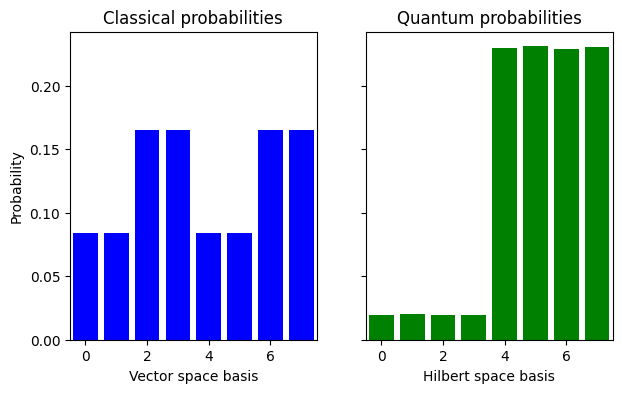

In [360]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

ax1.bar(np.arange(0, 2 ** n_qubits), xhat, color="blue")
ax1.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax1.set_xlabel("Vector space basis")
ax1.set_ylabel("Probability")
ax1.set_title("Classical probabilities")

ax2.bar(np.arange(0, 2 ** n_qubits), statevector, color="green")
ax2.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax2.set_xlabel("Hilbert space basis")
ax2.set_title("Quantum probabilities")

print(f"Classical: \n{xhat}\nQuantum: \n{statevector}")

plt.show()